# Location/Scale models on site-imbalance data.

site-imbalance scenarios occurs when the classes have different imbalance in each site. The extreme case of scenario is when one site is in charge or collecting all the patients and another site in charge of collecting the healthy controls.

In this case, the Effect of Site is correlated with the target of interest ComBat will not be able to separate the EoS from the True signal, unless we pass our target as covariate. Even when if we do not have a EoS, the target variance will be confounded as EoS for the model and it will try to remove it.

In this notebook we will simulate this scenario and apply NeuroComBat with and without preserving the target as covariate, and see the effect in a simple machine learning model.

<!-- # Analyzing Location/Scale behavior with class imbalance across sites

### In this notebook, we will explore what is the effect of applying ComBat on scenarios where the target and the site are dependent, e.g., the classes across sites are imbalanced.

This is a common scenario in real-world scenarios, when the majority of one class (patients) is acquired in a subset of sites, while the majority of another class (controls) is acquired in a different subset of sites.

Another common scenario is the non-overlapping age range in datasets. 

We will simulate two situations:

- First, we will harmonize the data without using the target to preserve the it's variance.
- Second, we will harmonize the data passing the target as a covariate to the harmonization model.

From these scenarios, only the first is compatible with a Machine Learning pipeline, as the target is unknown for the test samples. -->

In [4]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from uniharmony.datasets import make_multisite_classification
from uniharmony.plot import plot_decision_boundary_2d
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from uniharmony import verbosity
verbosity("error")

from uniharmony.combat import NeuroComBat

sns.set_theme(style="whitegrid")
random_state = 23

### Let's create an example where no EoS will be simulated, and only real signal will be presented.

To generate the site-target dependence, we will generate an imbalance problem by site, making 10% of the data in Site 0 to belong to Class 1.

In [8]:
# Data generation
X, y, sites = make_multisite_classification(
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.9],
    site_effect_homogeneous=True,
    site_effect_type="location",
    signal_type="blobs",
    random_state=random_state,
)

X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(
    X, y, sites
)

clf = LogisticRegression(random_state=random_state)
combat = NeuroComBat()

### Now let's apply our the harmonization in these two Scenarios.

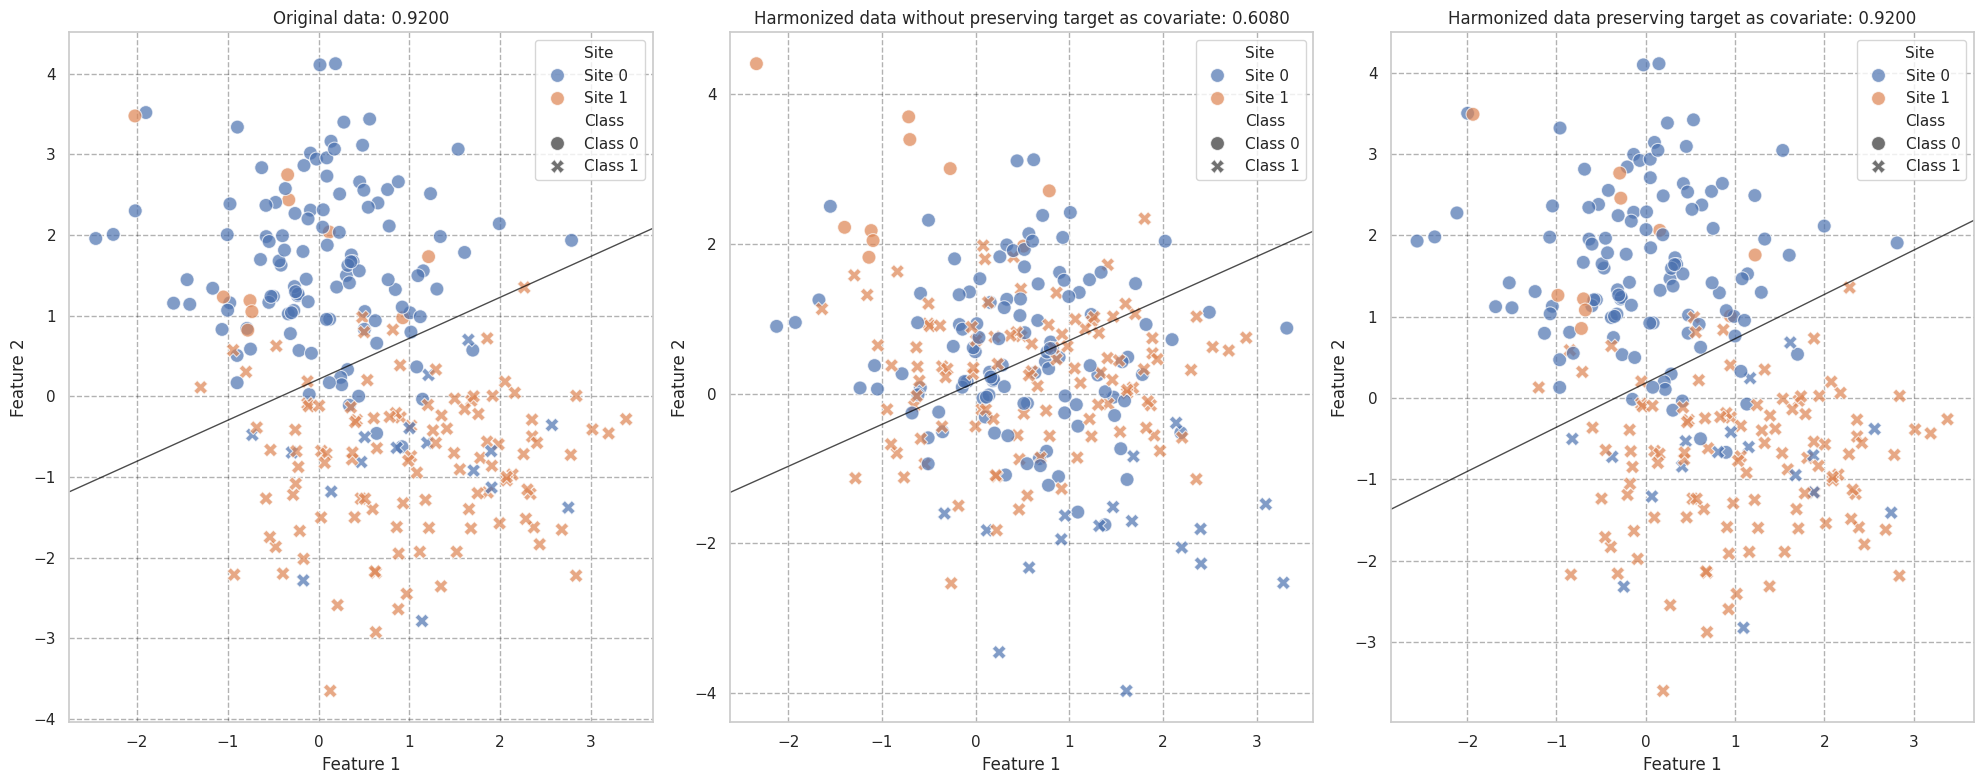

In [ ]:
# Harmonization

# Harmonizing without preserving the target as covariate
X_harmonized_train = combat.fit_transform(X=X_train, sites=sites_train)
X_harmonized = combat.transform(X_test, sites_test)


# Preserve the target as covariate
# This is the key line: we need to include the target variable as a covariate
# to preserve the  features's signal during harmonization.
X_harmonized_train_target = combat.fit_transform(
    X=X_train, sites=sites_train, categorical_covariates=y_train
)

#############################################################################################
# This step generally represent *data leakage* in a ML learning pipeline
# In most of the ML applications, the test target is unknown and is what we aim to predict.
# We should not be able to give this information to the harmonization model. 
X_harmonized_target = combat.transform(
    X_test, sites_test, categorical_covariates=y_test
)

#############################################################################################


####### Prepare data for plotting.
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X_test[:, 0],
        "Feature 2": X_test[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)

# Create DataFrame for easier plotting
df_harm = pd.DataFrame(
    {
        "Feature 1": X_harmonized[:, 0],
        "Feature 2": X_harmonized[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)


# Create DataFrame for easier plotting
df_harm_target = pd.DataFrame(
    {
        "Feature 1": X_harmonized_target[:, 0],
        "Feature 2": X_harmonized_target[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)

fig, ax = plt.subplots(1, 3, figsize=(20, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[0],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_train, y_train)
scores = clf.score(X_test, y_test)
ax[0].set_title(f"Original data: {scores:.4f}")
ax[0].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundary_2d(ax[0], clf)

# Plot with site as hue and class as style
sns.scatterplot(
    data=df_harm,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[1],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_harmonized_train, y_train)
scores = clf.score(X_harmonized, y_test)

ax[1].set_title(f"Harmonized data without preserving target as covariate: {scores:.4f}")
ax[1].grid(alpha=0.3, color="black", linestyle="--")

plot_decision_boundary_2d(ax[1], clf)
# Plot with site as hue and class as style
sns.scatterplot(
    data=df_harm_target,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[2],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_harmonized_train_target, y_train)
scores = clf.score(X_harmonized_target, y_test)

ax[2].set_title(f"Harmonized data preserving target as covariate: {scores:.4f}")
ax[2].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundary_2d(ax[2], clf)

plt.tight_layout()


### Take-home message

Location/Scale methods, in this case, NeuroComBat struggles to preserve the target variance in class imbalance scenarios unless we preserve it as a covariate.

An important clarification is that preserving the target as a covariate may be suited for statistical analysis, but violates the assumptions of ML scenarios.

# Questions
What do you think it would happen if EoS were simulated?

### Solution

You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block03)